# Model Dengue Nowcasting (ARX + Joint Loss)

This notebook implements Model according to the requirements:
- Training set: months **<= split_month** (rolling splits)
- Test set: months **> split_month** (for evaluation only)
- Joint loss: WHO monthly supervision + OpenDengue yearly constraints + L2 regularization
- Use Data preprocessing estimates to impute missing WHO observations as $\tilde{x}$ for lagged inputs
- Output complete parameters, training curves, predictions, and plots

Overfitting control: L2 regularization + early stopping + train/test split.

In [10]:
# If needed, install dependencies in your environment:
# pip install -U pandas numpy torch matplotlib

# Prevent kernel crashes from OpenMP/MKL library conflicts
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Further limit thread count
torch.set_num_threads(1)

In [11]:
@dataclass
class Step2Config:
    # Inputs
    # WHO observed target + Step 1 smooth predictions both come from preprocessing outputs.
    step1_predictions_path: str = os.path.join('preprocessing_outputs', 'preprocessed_monthly.csv')
    step1_pred_col: str = 'x_pred'
    step1_who_col: str = 'y_who'

    # Processed updater data (all non-WHO features / yearly constraints)
    monthly_data_path: str = os.path.join('dengue_updater', 'data', 'processed', 'monthly_data.csv')
    yearly_data_path: str = os.path.join('dengue_updater', 'data', 'processed', 'yearly_data.csv')

    # Modeling window
    start_month: str = '2021-01'

    # Rolling split evaluation
    # rolling_start / rolling_end are computed automatically at runtime
    # based on the last valid WHO month in preprocessing_outputs/preprocessed_monthly.csv:
    #   rolling_start = last_who_month - 12 months
    #   rolling_end   = last_who_month -  2 months
    test_horizon_months: int = 2
    rolling_max_epochs: int = 8000
    rolling_patience: int = 400

    # Target/source names in the working wide table
    target_source: str = 'WHO'

    # Exogenous signals (all from dengue_updater/data/processed/monthly_data.csv)
    google_sources: Tuple[str, str] = (
        'Google_Trends_Dengue_fever',
        'Google_Trends_Dengue_vaccine',
    )

    use_wiki: bool = True
    wiki_transform: str = 'log1p'  # 'log1p' or 'none'
    # Which wiki column to use from monthly_data.csv.
    # Set to 'wikipedia_total_dengue_views_normalized' to use old-style
    # multiplicative normalization (precomputed in the data pipeline).
    wiki_column: str = 'wikipedia_total_dengue_views_normalized'

    use_mosquito: bool = True
    mosquito_feature_cols: Tuple[str, ...] = ('TOTAL_MONTHLY_VIEWS',)
    mosquito_transform: str = 'log1p'  # 'log1p' or 'none'

    # Feature engineering
    lags_y: Tuple[int, ...] = (1, 2, 12)
    use_month_dummies: bool = False

    # Seasonality (periodic time series)
    seasonal_period: int = 12
    use_fourier: bool = True
    fourier_K: int = 2

    # Yearly proxy (current processed yearly file only contains national totals)
    yearly_proxy_sources_priority: Tuple[str, ...] = (
        'OpenDengue_National_Yearly',
    )

    # Loss weights
    lambda_who: float = 5.0
    lambda_year: float = 0.01
    lambda_reg: float = 0.01
    lambda_lag_reg: float = 0.001

    # Optimization
    epochs: int = 30000
    lr: float = 3e-3
    seed: int = 42
    target_scale: float = 1.0

    # Overfitting controls
    early_stop: bool = True
    patience: int = 1000
    min_delta: float = 1e-7

    # Scaling features (standardize using train stats)
    standardize_features: bool = True

    # Inference: approximate coefficient confidence intervals (normal approx via Hessian)
    compute_beta_ci: bool = True
    beta_ci_alpha: float = 0.05

    # Output
    outdir: str = 'outputs_updated_nowcast_log'
    clip_nonnegative: bool = False


cfg = Step2Config()
cfg


Step2Config(step1_predictions_path='preprocessing_outputs/preprocessed_monthly.csv', step1_pred_col='x_pred', step1_who_col='y_who', monthly_data_path='dengue_updater/data/processed/monthly_data.csv', yearly_data_path='dengue_updater/data/processed/yearly_data.csv', start_month='2021-01', test_horizon_months=2, rolling_max_epochs=8000, rolling_patience=400, target_source='WHO', google_sources=('Google_Trends_Dengue_fever', 'Google_Trends_Dengue_vaccine'), use_wiki=True, wiki_transform='log1p', wiki_column='wikipedia_total_dengue_views_normalized', use_mosquito=True, mosquito_feature_cols=('TOTAL_MONTHLY_VIEWS',), mosquito_transform='log1p', lags_y=(1, 2, 12), use_month_dummies=False, seasonal_period=12, use_fourier=True, fourier_K=2, yearly_proxy_sources_priority=('OpenDengue_National_Yearly',), lambda_who=5.0, lambda_year=0.01, lambda_reg=0.01, lambda_lag_reg=0.001, epochs=30000, lr=0.003, seed=42, target_scale=1.0, early_stop=True, patience=1000, min_delta=1e-07, standardize_features

In [12]:
def ensure_outdir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def parse_monthly_date_any(s: pd.Series) -> pd.Series:
    x = s.astype(str)
    is_ym = x.str.match('^[0-9]{4}-[0-9]{2}$')
    x = np.where(is_ym, x + '-01', x)
    dt = pd.to_datetime(x, errors='coerce')
    return dt


# ─── Data loaders — only the requested current files ─────────────────────────

def load_monthly_features(cfg: Step2Config) -> pd.DataFrame:
    """Load all non-WHO monthly features from dengue_updater/data/processed/monthly_data.csv."""
    path = cfg.monthly_data_path
    if not os.path.exists(path):
        raise FileNotFoundError(f"Monthly processed data not found: {path}")

    df = pd.read_csv(path)
    if 'date' not in df.columns:
        raise ValueError(f"monthly_data.csv missing 'date' column: {path}")

    df['date'] = parse_monthly_date_any(df['date'])
    df = df.dropna(subset=['date']).sort_values('date').copy()

    required = [
        'google_trends_dengue_fever',
        'google_trends_dengue_vaccine',
        'wikipedia_total_dengue_views',
        'wikipedia_mosquito_views_total',
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"monthly_data.csv missing required columns: {missing}")
    # Also require the normalized wiki column (produced by dengue_updater pipeline)
    if 'wikipedia_total_dengue_views_normalized' not in df.columns:
        import warnings
        warnings.warn(
            "wikipedia_total_dengue_views_normalized not found in monthly_data.csv — "
            "wiki_column will fall back to wikipedia_total_dengue_views"
        )

    # Fix: set_index BEFORE column selection to avoid pandas index-alignment bug
    # (old pattern: wide=DataFrame(DatetimeIndex) then wide[col]=df[col] with RangeIndex
    #  → pandas aligns by label → all values become NaN)
    df = df.set_index('date')
    cols = [
        'google_trends_dengue_fever',
        'google_trends_dengue_vaccine',
        'wikipedia_total_dengue_views',
        'wikipedia_mosquito_views_total',
    ]
    if 'wikipedia_total_dengue_views_normalized' in df.columns:
        cols.append('wikipedia_total_dengue_views_normalized')
    wide = df[cols].apply(pd.to_numeric, errors='coerce').copy()
    wide = wide.rename(columns={
        'google_trends_dengue_fever':  'Google_Trends_Dengue_fever',
        'google_trends_dengue_vaccine': 'Google_Trends_Dengue_vaccine',
    })
    return wide.sort_index()


def load_preprocessing_monthly(cfg: Step2Config) -> pd.DataFrame:
    """Load Step 1 predictions + WHO observed target from preprocessing_outputs/preprocessed_monthly.csv."""
    path = cfg.step1_predictions_path
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Preprocessing output not found: {path}\n"
            "Run preprocessing.py first to generate preprocessing_outputs/preprocessed_monthly.csv"
        )

    df = pd.read_csv(path)
    if 'date' not in df.columns:
        raise ValueError(f"preprocessed_monthly.csv missing 'date' column: {path}")

    required = [cfg.step1_pred_col, cfg.step1_who_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"preprocessed_monthly.csv missing required columns: {missing}")

    df['date'] = parse_monthly_date_any(df['date'])
    df = df.dropna(subset=['date']).sort_values('date').copy()
    return df


def load_step1_predictions(cfg: Step2Config) -> pd.Series:
    df = load_preprocessing_monthly(cfg)
    return pd.Series(
        pd.to_numeric(df[cfg.step1_pred_col], errors='coerce').values,
        index=pd.DatetimeIndex(df['date']),
        name=cfg.step1_pred_col,
    )


def load_who_from_preprocessing(cfg: Step2Config) -> pd.Series:
    df = load_preprocessing_monthly(cfg)
    return pd.Series(
        pd.to_numeric(df[cfg.step1_who_col], errors='coerce').values,
        index=pd.DatetimeIndex(df['date']),
        name='WHO',
    )


def load_yearly_proxy(cfg: Step2Config) -> pd.DataFrame:
    """Load yearly constraints from dengue_updater/data/processed/yearly_data.csv."""
    path = cfg.yearly_data_path
    if not os.path.exists(path):
        raise FileNotFoundError(f"Yearly processed data not found: {path}")

    df = pd.read_csv(path)
    required = ['year', 'open_dengue_national_yearly']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"yearly_data.csv missing required columns: {missing}")

    out = df[required].copy()
    out['year'] = pd.to_numeric(out['year'], errors='coerce').astype('Int64')
    out['od_total'] = pd.to_numeric(out['open_dengue_national_yearly'], errors='coerce')
    out = out.dropna(subset=['year', 'od_total']).copy()
    out['year'] = out['year'].astype(int)
    out['od_source'] = 'OpenDengue_National_Yearly'
    return out[['year', 'od_total', 'od_source']].sort_values('year').reset_index(drop=True)


def build_model_wide(cfg: Step2Config) -> pd.DataFrame:
    """Create the single monthly wide table used by Step 2.

    Sources:
      - Google / wiki / mosquito features: dengue_updater/data/processed/monthly_data.csv
      - WHO observed target: preprocessing_outputs/preprocessed_monthly.csv (y_who)
      - Step 1 smooth predictions: preprocessing_outputs/preprocessed_monthly.csv (x_pred)
    """
    feat = load_monthly_features(cfg)
    prep = load_preprocessing_monthly(cfg).set_index('date')

    wide = feat.copy()
    wide['WHO'] = pd.to_numeric(prep[cfg.step1_who_col], errors='coerce').reindex(wide.index)
    wide['STEP1_est'] = pd.to_numeric(prep[cfg.step1_pred_col], errors='coerce').reindex(wide.index)
    return wide.sort_index()


def build_design_matrix(wide: pd.DataFrame, cfg: Step2Config) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """Build design matrix using only current processed updater files + preprocessing WHO / Step1 signal."""
    start_dt = pd.to_datetime(cfg.start_month + '-01')
    wide = wide.loc[wide.index >= start_dt].copy()

    g1, g2 = cfg.google_sources
    for g in [g1, g2]:
        if g not in wide.columns:
            raise ValueError(f"Missing Google source '{g}' in monthly features table.")

    if cfg.target_source not in wide.columns:
        raise ValueError(f"Missing target source '{cfg.target_source}' in working wide table.")

    y_who_series = pd.to_numeric(wide[cfg.target_source], errors='coerce')
    if 'STEP1_est' not in wide.columns:
        raise ValueError("Missing STEP1_est in working wide table.")

    x_tilde_raw = y_who_series.where(y_who_series.notna(), pd.to_numeric(wide['STEP1_est'], errors='coerce'))
    x_tilde_scaled = np.log1p(x_tilde_raw)

    X_df = pd.DataFrame(index=wide.index)
    X_df['g_fever'] = pd.to_numeric(wide[g1], errors='coerce') / 100.0
    X_df['g_vaccine'] = pd.to_numeric(wide[g2], errors='coerce') / 100.0

    if getattr(cfg, 'use_wiki', False):
        _wiki_col = getattr(cfg, 'wiki_column', 'wikipedia_total_dengue_views')
        if _wiki_col not in wide.columns:
            import warnings
            warnings.warn(
                f"wiki_column '{_wiki_col}' not found in wide — falling back to "
                "'wikipedia_total_dengue_views'"
            )
            _wiki_col = 'wikipedia_total_dengue_views'
        wiki_raw = pd.to_numeric(wide[_wiki_col], errors='coerce')
        if str(getattr(cfg, 'wiki_transform', 'log1p')).lower() == 'log1p':
            X_df['wiki_views'] = np.log1p(wiki_raw.astype(float))
        else:
            X_df['wiki_views'] = wiki_raw.astype(float)

    if getattr(cfg, 'use_mosquito', False):
        raw = pd.to_numeric(wide['wikipedia_mosquito_views_total'], errors='coerce')
        out_col = 'mosq_total_monthly_views'
        if str(getattr(cfg, 'mosquito_transform', 'log1p')).lower() == 'log1p':
            X_df[out_col] = np.log1p(raw.astype(float))
        else:
            X_df[out_col] = raw.astype(float)

    for k in cfg.lags_y:
        X_df[f'x_tilde_lag{k}'] = x_tilde_scaled.shift(k)

    if getattr(cfg, 'use_fourier', False):
        X_df = add_fourier_features(
            X_df,
            period=int(getattr(cfg, 'seasonal_period', 12)),
            K=int(getattr(cfg, 'fourier_K', 2)),
            prefix='s'
        )
    elif cfg.use_month_dummies:
        X_df = add_month_dummies(X_df)

    X_df['intercept'] = 1.0

    exo_cols = ['g_fever', 'g_vaccine']
    if 'wiki_views' in X_df.columns:
        exo_cols.append('wiki_views')
    exo_cols += [c for c in X_df.columns if c.startswith('mosq_')]
    for col in exo_cols:
        if col in X_df.columns:
            X_df[col] = X_df[col].interpolate(limit_direction='both').ffill().bfill()

    feature_cols = [c for c in X_df.columns if c != 'intercept'] + ['intercept']
    X = X_df[feature_cols].to_numpy(dtype=np.float32)
    y = y_who_series.to_numpy(dtype=np.float32)
    mask_who = np.isfinite(y)

    return X_df, X, y, mask_who, feature_cols


def add_month_dummies(df: pd.DataFrame) -> pd.DataFrame:
    dt = pd.to_datetime(df.index)
    m = pd.get_dummies(dt.month, prefix='m', drop_first=True)
    m.index = df.index
    return pd.concat([df, m.astype(float)], axis=1)


def add_fourier_features(df: pd.DataFrame, period: int = 12, K: int = 2, prefix: str = 's') -> pd.DataFrame:
    """Add Fourier seasonality terms based on month-of-year."""
    dt = pd.to_datetime(df.index)
    m = dt.month.astype(float)
    out = df.copy()
    for k in range(1, int(K) + 1):
        out[f'{prefix}_sin{k}'] = np.sin(2 * np.pi * k * m / float(period))
        out[f'{prefix}_cos{k}'] = np.cos(2 * np.pi * k * m / float(period))
    return out


def build_year_constraints(dates: pd.DatetimeIndex, yearly_proxy: pd.DataFrame, train_mask: np.ndarray) -> List[tuple]:
    df_dates = pd.DataFrame({'date': pd.to_datetime(dates)})
    df_dates['year'] = df_dates['date'].dt.year
    df_dates['month'] = df_dates['date'].dt.month

    constraints = []
    for _, r in yearly_proxy.iterrows():
        y = int(r['year'])
        od_total = float(r['od_total'])
        od_src = str(r['od_source'])

        idx = df_dates.index[df_dates['year'].eq(y)].to_numpy()
        if len(idx) == 0:
            continue

        months_present = set(df_dates.loc[idx, 'month'].tolist())
        if months_present != set(range(1, 13)):
            continue
        if not np.all(train_mask[idx]):
            continue

        constraints.append((y, idx, od_total, od_src))

    return constraints


def time_series_split_mask(index: pd.DatetimeIndex, split_month: str, horizon_months: int = 2):
    split_dt = pd.to_datetime(split_month + '-01')
    test_end_dt = split_dt + pd.DateOffset(months=int(horizon_months))
    train_mask = index <= split_dt
    test_mask = (index > split_dt) & (index <= test_end_dt)
    return train_mask, test_mask


def standardize_features(X: np.ndarray, train_mask: np.ndarray, skip_cols: List[int] = None):
    """Standardize feature matrix using train-set statistics only."""
    X2 = X.copy()
    n, p = X2.shape
    means = np.zeros(p, dtype=np.float32)
    stds = np.ones(p, dtype=np.float32)

    if skip_cols is None:
        skip_cols = []

    for j in range(p):
        col = X2[:, j]
        col_train = col[train_mask]

        if j in skip_cols:
            col = np.where(np.isfinite(col), col, 0.0)
            X2[:, j] = col
            continue

        m = np.nanmean(col_train)
        s = np.nanstd(col_train)
        if not np.isfinite(m):
            m = 0.0
        if (not np.isfinite(s)) or s <= 1e-12:
            s = 1.0
        means[j] = m
        stds[j] = s

        col = np.where(np.isfinite(col), col, m)
        X2[:, j] = (col - m) / s

    return X2, means, stds


def train_step2_joint_loss(
    X: np.ndarray,
    y_who: np.ndarray,
    mask_who: np.ndarray,
    year_constraints: List[tuple],
    train_mask: np.ndarray,
    cfg: Step2Config,
    feature_cols: List[str],
    ):
    """Train with differentiated regularization: stronger penalty on lag coefficients."""
    device = torch.device('cpu')

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_scaled = np.log1p(np.maximum(y_who, 0.0))
    y_t = torch.tensor(y_scaled, dtype=torch.float32, device=device)
    mask_who_t = torch.tensor(mask_who & train_mask, dtype=torch.bool, device=device)

    year_terms = []
    for (year, idx, od_total, od_src) in year_constraints:
        year_terms.append(
            (year, torch.tensor(idx, dtype=torch.long, device=device), float(len(idx) * np.log1p(float(od_total) / len(idx))), od_src)
        )

    lag_indices = [i for i, col in enumerate(feature_cols) if 'lag' in col.lower()]

    p = X_t.shape[1]
    beta = torch.nn.Parameter(torch.zeros(p, dtype=torch.float32, device=device))
    opt = torch.optim.Adam([beta], lr=cfg.lr)

    rows = []
    best_loss = np.inf
    best_beta = None
    bad_epochs = 0

    for epoch in range(1, cfg.epochs + 1):
        opt.zero_grad(set_to_none=True)
        x = X_t @ beta

        if mask_who_t.any():
            diff_who = x[mask_who_t] - y_t[mask_who_t]
            L_who = (diff_who ** 2).mean()
        else:
            L_who = torch.tensor(0.0, device=device)

        if len(year_terms) > 0:
            diffs = []
            for _, idx_t, od_total_scaled, _ in year_terms:
                year_sum = x.index_select(0, idx_t).sum()
                diffs.append((year_sum - od_total_scaled) ** 2)
            L_year = torch.stack(diffs).mean()
        else:
            L_year = torch.tensor(0.0, device=device)

        L_reg_base = (beta ** 2).sum()
        if lag_indices:
            beta_lag = beta[lag_indices]
            L_reg_lag = (beta_lag ** 2).sum()
        else:
            L_reg_lag = torch.tensor(0.0, device=device)

        L_reg = L_reg_base
        L_total = cfg.lambda_who * L_who + cfg.lambda_year * L_year + cfg.lambda_reg * L_reg + cfg.lambda_lag_reg * L_reg_lag
        L_total.backward()
        opt.step()

        val = float(L_total.detach().cpu().item())
        rows.append({
            'epoch': epoch,
            'L_total': val,
            'L_who': float(L_who.detach().cpu().item()),
            'L_year': float(L_year.detach().cpu().item()),
            'L_reg': float(L_reg.detach().cpu().item()),
            'L_lag_reg': float(L_reg_lag.detach().cpu().item()) if lag_indices else 0.0,
        })

        if not np.isfinite(val):
            raise RuntimeError('Training diverged (loss is NaN/Inf).')

        if cfg.early_stop:
            if val < best_loss - cfg.min_delta:
                best_loss = val
                best_beta = beta.detach().cpu().numpy().copy()
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= cfg.patience:
                    break

    beta_hat = beta.detach().cpu().numpy() if best_beta is None else best_beta
    loss_df = pd.DataFrame(rows)
    return beta_hat, loss_df


def compute_rolling_split_range(wide, target_source='WHO', back_start=12, back_end=2):
    """Automatically determine rolling CV split range from the last valid WHO month."""
    if target_source not in wide.columns:
        raise ValueError(
            f"Target source '{target_source}' not found in wide DataFrame. "
            f"Available columns: {list(wide.columns)}"
        )

    who_series = pd.to_numeric(wide[target_source], errors='coerce')
    valid_months = who_series.dropna().index
    if len(valid_months) == 0:
        raise ValueError(
            f"No valid (non-NaN) months found for source '{target_source}'. "
            "Cannot auto-compute rolling split range."
        )

    last_who_month = valid_months.max()
    start_dt = last_who_month - pd.DateOffset(months=back_start)
    end_dt = last_who_month - pd.DateOffset(months=back_end)

    rolling_start = start_dt.strftime('%Y-%m')
    rolling_end = end_dt.strftime('%Y-%m')

    rolling_split_months = (
        pd.period_range(rolling_start, rolling_end, freq='M')
        .strftime('%Y-%m')
        .tolist()
    )

    return rolling_start, rolling_end, last_who_month, rolling_split_months


In [13]:

def compute_rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))

def compute_mse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.nanmean((y_true - y_pred) ** 2))


def safe_mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-12, np.nan, np.abs(y_true))
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0)


def make_predictions(X: np.ndarray, beta_hat: np.ndarray, cfg: Step2Config) -> np.ndarray:
    x_log = X @ beta_hat  # prediction in log1p-space
    x = np.expm1(x_log)   # back-transform to WHO units; always > -1
    if cfg.clip_nonnegative:
        x = np.maximum(x, 0.0)
    return x


def plot_loss_curve(loss_df: pd.DataFrame, outdir: Path) -> None:
    fig = plt.figure()
    plt.plot(loss_df['epoch'], loss_df['L_total'], label='Total')
    if (loss_df['L_who'] != 0).any():
        plt.plot(loss_df['epoch'], loss_df['L_who'], label='WHO')
    if (loss_df['L_year'] != 0).any():
        plt.plot(loss_df['epoch'], loss_df['L_year'], label='Yearly')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss Curve (Step 2)')
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    fig.savefig(outdir / 'loss_curve_step2.png', dpi=200)
    plt.close(fig)



def plot_who_vs_pred(
    dates: pd.DatetimeIndex,
    y_who: np.ndarray,
    x_pred: np.ndarray,
    train_mask: np.ndarray,
    test_mask: np.ndarray,
    outdir: Path,
    fname: str = 'who_vs_pred_step2.png',
    title: str = None,
    x_step1: Optional[np.ndarray] = None,
    legend_loc: str = 'best',
) -> None:
    fig = plt.figure(figsize=(10, 4))

    display_mask = np.asarray(train_mask, dtype=bool) | np.asarray(test_mask, dtype=bool)
    x_pred_plot = np.asarray(x_pred, dtype=float).copy()
    x_pred_plot[~display_mask] = np.nan

    split_dt = dates[train_mask].max() if np.asarray(train_mask).any() else None
    test_end_dt = dates[test_mask].max() if np.asarray(test_mask).any() else None

    if split_dt is not None and test_end_dt is not None and test_end_dt >= split_dt:
        plt.axvspan(split_dt, test_end_dt, alpha=0.10, color='gray', zorder=0)

    plt.plot(dates, x_pred_plot, label='Predicted (Model)')
    plt.plot(dates, y_who, label='WHO observed')

    # Optional: overlay Step 1 predictions only for historical missing WHO months.
    # Future Step 1 extrapolation (purple line in the old plot) is intentionally removed.
    if x_step1 is not None:
        x_step1 = np.asarray(x_step1, dtype=float)
        y_who_arr = np.asarray(y_who, dtype=float)

        who_idx = np.where(np.isfinite(y_who_arr))[0]
        last_who = int(who_idx.max()) if who_idx.size > 0 else -1

        miss_mask = (~np.isfinite(y_who_arr)) & np.isfinite(x_step1)
        miss_idx = np.where(miss_mask)[0]

        if miss_idx.size > 0:
            runs = []
            s = miss_idx[0]
            prev = miss_idx[0]
            for k in miss_idx[1:]:
                if k == prev + 1:
                    prev = k
                else:
                    runs.append((s, prev))
                    s = prev = k
            runs.append((s, prev))

            first_hist = True

            for (a, b) in runs:
                # keep only historical missing blocks, not future extrapolation blocks
                if a > last_who:
                    continue

                seg_dates = list(dates[a:b + 1])
                seg_vals = list(x_step1[a:b + 1])

                if a - 1 >= 0 and np.isfinite(y_who_arr[a - 1]):
                    seg_dates = [dates[a - 1]] + seg_dates
                    seg_vals = [y_who_arr[a - 1]] + seg_vals

                if b + 1 < len(dates) and np.isfinite(y_who_arr[b + 1]):
                    seg_dates = seg_dates + [dates[b + 1]]
                    seg_vals = seg_vals + [y_who_arr[b + 1]]

                label = 'Data preprocessing (only where WHO is missing)' if first_hist else None
                first_hist = False
                plt.plot(seg_dates, seg_vals, color='#2ecc71', linewidth=2.5, label=label)

    if x_step1 is not None:
        y_who_arr = np.asarray(y_who, dtype=float)
        who_idx = np.where(np.isfinite(y_who_arr))[0]
        if who_idx.size > 0:
            first_who = who_idx.min()
            if first_who > 0 and (~np.isfinite(y_who_arr[:first_who])).any():
                plt.axvline(
                    dates[first_who],
                    linestyle=':',
                    color='black',
                    linewidth=2.0,
                    label='WHO begins'
                )

    if split_dt is not None:
        plt.axvline(split_dt, linestyle='--', color='gray', label='Train/Test split')
    if test_end_dt is not None:
        plt.axvline(test_end_dt, linestyle='--', color='lightgray', label='2-month test end')

    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title(title if title is not None else 'WHO vs Prediction (Model)')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / fname, dpi=200)
    plt.close(fig)



def plot_yearly_vs_od(pred_df: pd.DataFrame, yearly_proxy: pd.DataFrame, outdir: Path) -> None:
    pred_year = pred_df.groupby('year', as_index=False)['x_pred'].sum().rename(columns={'x_pred': 'pred_year_total'})
    if yearly_proxy.empty:
        return
    merged = pred_year.merge(yearly_proxy, on='year', how='inner').sort_values('year')

    fig = plt.figure()
    plt.plot(merged['year'], merged['pred_year_total'], marker='o', label='Predicted yearly sum')
    plt.plot(merged['year'], merged['od_total'], marker='o', label='OpenDengue yearly total')
    plt.xlabel('Year')
    plt.ylabel('Total dengue cases (year)')
    plt.title('Yearly Aggregation: Prediction vs OpenDengue (Model)')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / 'yearly_vs_opendengue_step2.png', dpi=200)
    plt.close(fig)

    merged.to_csv(outdir / 'yearly_comparison_step2.csv', index=False)



def plot_step1_vs_step2(pred_df: pd.DataFrame, outdir: Path):
    if 'x_step1' not in pred_df.columns:
        return
    fig = plt.figure(figsize=(10, 4))
    dates = pd.to_datetime(pred_df['date'] + '-01')
    plt.plot(dates, pred_df['x_step1'], label='Data preprocessing')
    plt.plot(dates, pred_df['x_pred'], label='Model')
    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title('Data preprocessing vs Model')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / 'step1_vs_step2.png', dpi=200)
    plt.close(fig)


from statistics import NormalDist

def compute_beta_ci_hessian(
    X: np.ndarray,
    y_who: np.ndarray,
    mask_who: np.ndarray,
    year_constraints: List[tuple],
    train_mask: np.ndarray,
    cfg: Step2Config,
    feature_cols: List[str],
    beta_hat: np.ndarray,
    feat_mean: Optional[np.ndarray] = None,
    feat_std: Optional[np.ndarray] = None,
    intercept_idx: Optional[int] = None,
    alpha: Optional[float] = None,
) -> dict:
    """
    Approximate coefficient confidence intervals under a Gaussian noise model
    on WHO-observed training months, using a normal approximation from the
    (quadratic) objective Hessian.

    Notes:
      - Treats yearly totals as deterministic constraints (no noise).
      - Returns CIs for:
          * beta (scaled target units)
          * coef_y_units_per_stdX (WHO units per 1 std of X, if standardized)
          * coef_y_units_per_rawX (WHO units per 1 raw-unit of X, if standardized)
    """
    if alpha is None:
        alpha = float(getattr(cfg, 'beta_ci_alpha', 0.05))

    beta_hat = np.asarray(beta_hat, dtype=float)
    p = beta_hat.shape[0]

    who_train_mask = (mask_who.astype(bool) & train_mask.astype(bool))
    idx = np.where(who_train_mask)[0]
    n_who = int(idx.size)
    if n_who == 0:
        nan = np.full(p, np.nan, dtype=float)
        return dict(
            beta_se=nan, beta_ci_lo=nan, beta_ci_hi=nan,
            coef_std_se=nan, coef_std_ci_lo=nan, coef_std_ci_hi=nan,
            coef_raw_se=nan, coef_raw_ci_lo=nan, coef_raw_ci_hi=nan,
            sigma2=np.nan, df_eff=np.nan,
        )

    Xw = np.asarray(X[idx, :], dtype=float)
    y_scaled = np.log1p(np.maximum(np.asarray(y_who[idx], dtype=float), 0.0))  # log1p inside CI

    # Build Hessian (scaled units, matches train_step2_joint_loss)
    lam_who = float(cfg.lambda_who)
    lam_year = float(cfg.lambda_year)
    lam_reg = float(cfg.lambda_reg)
    lam_lag = float(cfg.lambda_lag_reg)

    # WHO term: (lam_who / n_who) * ||Xw beta - y||^2
    H_core = (lam_who / n_who) * (Xw.T @ Xw)

    # Year constraints term: (lam_year / n_year) * sum_y (c_y^T beta - od_y)^2
    n_year = int(len(year_constraints))
    if n_year > 0 and lam_year != 0.0:
        for (_, idx_year, od_total, _) in year_constraints:
            c = np.asarray(X[np.asarray(idx_year, dtype=int), :], dtype=float).sum(axis=0)
            H_core += (lam_year / n_year) * np.outer(c, c)

    # Regularization terms
    H_core += lam_reg * np.eye(p, dtype=float)

    lag_indices = [i for i, col in enumerate(feature_cols) if 'lag' in str(col).lower()]
    if lag_indices and lam_lag != 0.0:
        D = np.zeros(p, dtype=float)
        D[np.asarray(lag_indices, dtype=int)] = 1.0
        H_core += lam_lag * np.diag(D)

    # Full Hessian of L_total
    Hess = 2.0 * H_core

    # Invert Hessian (small p; ridge-like => should be well-conditioned)
    try:
        Hess_inv = np.linalg.inv(Hess)
    except np.linalg.LinAlgError:
        Hess_inv = np.linalg.pinv(Hess)

    # Effective degrees of freedom for WHO fitted values (approx.)
    XtX = Xw.T @ Xw
    df_eff = (2.0 * lam_who / n_who) * float(np.trace(XtX @ Hess_inv))

    # Residual variance estimate on WHO-observed training months (scaled)
    r = (Xw @ beta_hat) - y_scaled
    RSS = float(np.sum(r ** 2))
    denom = max(n_who - df_eff, 1.0)
    sigma2 = RSS / denom

    # Var(beta_hat) = sigma2 * A A^T, A = Hess_inv * (2 lam_who / n_who) * Xw^T
    cfac = (2.0 * lam_who / n_who)
    Var_beta = sigma2 * (cfac ** 2) * (Hess_inv @ XtX @ Hess_inv)

    se_beta = np.sqrt(np.clip(np.diag(Var_beta), 0.0, np.inf))

    z = float(NormalDist().inv_cdf(1.0 - alpha / 2.0))
    ci_lo = beta_hat - z * se_beta
    ci_hi = beta_hat + z * se_beta

    # Convert to WHO units per standardized X
    coef_std = beta_hat * float(cfg.target_scale)
    coef_std_se = se_beta * float(cfg.target_scale)
    coef_std_ci_lo = ci_lo * float(cfg.target_scale)
    coef_std_ci_hi = ci_hi * float(cfg.target_scale)

    # Convert to WHO units per raw X (requires feat_std/feat_mean if standardized)
    if (feat_std is not None) and (feat_mean is not None):
        feat_std = np.asarray(feat_std, dtype=float)
        feat_mean = np.asarray(feat_mean, dtype=float)

        # Transform covariance into coef_std space
        Var_coef_std = (float(cfg.target_scale) ** 2) * Var_beta

        # Build linear transform T: coef_std -> coef_raw (including intercept adjustment)
        T = np.zeros((p, p), dtype=float)
        for j in range(p):
            T[j, j] = 1.0 / float(feat_std[j]) if float(feat_std[j]) != 0.0 else 0.0

        if intercept_idx is not None:
            # intercept_raw = coef_std[int] - sum_j mean_j * (coef_std[j]/std_j)
            T[intercept_idx, :] = 0.0
            T[intercept_idx, intercept_idx] = 1.0
            for j in range(p):
                if j == intercept_idx:
                    continue
                stdj = float(feat_std[j]) if float(feat_std[j]) != 0.0 else 1.0
                T[intercept_idx, j] = - float(feat_mean[j]) / stdj

        Var_coef_raw = T @ Var_coef_std @ T.T
        se_raw = np.sqrt(np.clip(np.diag(Var_coef_raw), 0.0, np.inf))
        coef_raw = (coef_std / feat_std)
        if intercept_idx is not None:
            coef_raw = coef_raw.copy()
            coef_raw[intercept_idx] = coef_std[intercept_idx] - float(np.dot(coef_raw, feat_mean))

        coef_raw_ci_lo = coef_raw - z * se_raw
        coef_raw_ci_hi = coef_raw + z * se_raw
    else:
        se_raw = np.full(p, np.nan, dtype=float)
        coef_raw = np.full(p, np.nan, dtype=float)
        coef_raw_ci_lo = np.full(p, np.nan, dtype=float)
        coef_raw_ci_hi = np.full(p, np.nan, dtype=float)

    return dict(
        beta_se=se_beta,
        beta_ci_lo=ci_lo,
        beta_ci_hi=ci_hi,
        coef_std_se=coef_std_se,
        coef_std_ci_lo=coef_std_ci_lo,
        coef_std_ci_hi=coef_std_ci_hi,
        coef_raw_se=se_raw,
        coef_raw_ci_lo=coef_raw_ci_lo,
        coef_raw_ci_hi=coef_raw_ci_hi,
        Var_beta=Var_beta,
        z=z,
        sigma2=sigma2,
        df_eff=df_eff,
    )


## 1) Load Data, Build Features, and Split Train/Test

- Use Data preprocessing predictions to impute missing WHO observations for $\tilde{x}$
- Build ARX features: Google Trends + lagged variables + month dummies
- Training/Test split is evaluated over a rolling set of split months.

In [14]:
import copy
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# DATA SOURCE SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
#   WHO observed (target)   : preprocessing_outputs/preprocessed_monthly.csv (y_who column)
#   Step 1 predictions      : preprocessing_outputs/preprocessed_monthly.csv (x_pred column)
#   Google Trends features  : dengue_updater/data/processed/monthly_data.csv
#   Wikipedia dengue views  : dengue_updater/data/processed/monthly_data.csv
#   Wikipedia mosquito views: dengue_updater/data/processed/monthly_data.csv
#   OpenDengue yearly       : dengue_updater/data/processed/yearly_data.csv
# ══════════════════════════════════════════════════════════════════════════════

print("=== DATA SOURCE SUMMARY ===")
print(f"  Features source     : {cfg.monthly_data_path}")
print(f"  WHO observed source : {cfg.step1_predictions_path} ({cfg.step1_who_col} column)")
print(f"  Step1 predictions   : {cfg.step1_predictions_path} ({cfg.step1_pred_col} column)")
print(f"  Yearly data source  : {cfg.yearly_data_path}")
print()

# Load data — only the requested current files
wide = build_model_wide(cfg)
yearly_proxy = load_yearly_proxy(cfg)

X_df, X_raw, y_who, mask_who, feature_cols = build_design_matrix(wide, cfg)

# Step 1 predictions aligned to the full monthly index (used only for plotting overlays)
step1_full = load_step1_predictions(cfg).reindex(X_df.index).to_numpy(dtype=float)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print("=== SANITY CHECKS ===")
print(f"  Wide DataFrame shape : {wide.shape}")
print(f"  Wide columns         : {list(wide.columns)}")

assert 'Google_Trends_Dengue_fever' in wide.columns, "MISSING: Google_Trends_Dengue_fever in monthly_data.csv"
assert 'Google_Trends_Dengue_vaccine' in wide.columns, "MISSING: Google_Trends_Dengue_vaccine in monthly_data.csv"
assert 'wikipedia_total_dengue_views' in wide.columns, "MISSING: wikipedia_total_dengue_views in monthly_data.csv"
assert 'wikipedia_mosquito_views_total' in wide.columns, "MISSING: wikipedia_mosquito_views_total in monthly_data.csv"
assert 'WHO' in wide.columns, "MISSING: WHO column built from preprocessing_outputs/preprocessed_monthly.csv"
assert 'STEP1_est' in wide.columns, "MISSING: STEP1_est column built from preprocessing_outputs/preprocessed_monthly.csv"
assert 'g_fever' in X_df.columns, "MISSING: g_fever in design matrix"
assert 'g_vaccine' in X_df.columns, "MISSING: g_vaccine in design matrix"
assert 'wiki_views' in X_df.columns, "MISSING: wiki_views in design matrix"
assert any(c.startswith('mosq_') for c in X_df.columns), "MISSING: mosquito feature in design matrix"
assert mask_who.sum() > 0, "No WHO observations found in preprocessing_outputs/preprocessed_monthly.csv"

print(f"  Total months         : {len(X_df)}")
print(f"  WHO observed months  : {int(mask_who.sum())}  (from preprocessing_outputs/preprocessed_monthly.csv)")
print(f"  Feature count        : {X_raw.shape[1]}")
print(f"  Feature cols         : {feature_cols}")
print()

# ── Auto-compute rolling split range ─────────────────────────────────────────
rolling_start, rolling_end, last_who_month, rolling_split_months = compute_rolling_split_range(
    wide,
    target_source=cfg.target_source,
    back_start=12,
    back_end=0,
)

print("=== ROLLING SPLIT RANGE (auto-computed) ===")
print(f"  Last valid WHO month : {last_who_month.strftime('%Y-%m')}")
print(f"  Rolling start        : {rolling_start}  (last_who - 12 months)")
print(f"  Rolling end          : {rolling_end}  (last_who -  0 months)")
print(f"  Rolling split months : {rolling_split_months}")
print(f"  Test horizon         : {cfg.test_horizon_months} months")


=== DATA SOURCE SUMMARY ===
  Features source     : dengue_updater/data/processed/monthly_data.csv
  WHO observed source : preprocessing_outputs/preprocessed_monthly.csv (y_who column)
  Step1 predictions   : preprocessing_outputs/preprocessed_monthly.csv (x_pred column)
  Yearly data source  : dengue_updater/data/processed/yearly_data.csv

=== SANITY CHECKS ===
  Wide DataFrame shape : (64, 7)
  Wide columns         : ['Google_Trends_Dengue_fever', 'Google_Trends_Dengue_vaccine', 'wikipedia_total_dengue_views', 'wikipedia_mosquito_views_total', 'wikipedia_total_dengue_views_normalized', 'WHO', 'STEP1_est']
  Total months         : 64
  WHO observed months  : 26  (from preprocessing_outputs/preprocessed_monthly.csv)
  Feature count        : 12
  Feature cols         : ['g_fever', 'g_vaccine', 'wiki_views', 'mosq_total_monthly_views', 'x_tilde_lag1', 'x_tilde_lag2', 'x_tilde_lag12', 's_sin1', 's_cos1', 's_sin2', 's_cos2', 'intercept']

=== ROLLING SPLIT RANGE (auto-computed) ===
  Last 

## 2) Train Model (Joint Loss + Yearly Constraints + Early Stopping)

- Only training period participates in optimization
- WHO monthly + yearly proxy + L2 regularization
- Early stopping to prevent overfitting

In [15]:

# Rolling train/test split evaluation: each split trains up to split_month
# and tests only on the next cfg.test_horizon_months months.
outdir = Path(cfg.outdir)
roll_dir = outdir / 'rolling_splits'
ensure_outdir(str(roll_dir))

metric_rows = []
coef_rows = []
pred_rows = []

# Find intercept column index (should not be standardized)
intercept_idx = feature_cols.index('intercept') if 'intercept' in feature_cols else None
skip_cols = [intercept_idx] if intercept_idx is not None else []

for split_month in rolling_split_months:
    train_mask, test_mask = time_series_split_mask(
        X_df.index,
        split_month,
        horizon_months=int(cfg.test_horizon_months),
    )

    if int(train_mask.sum()) == 0 or int(test_mask.sum()) == 0:
        continue

    # Standardize features (using training set statistics only, skip intercept)
    if cfg.standardize_features:
        X_proc, feat_mean, feat_std = standardize_features(X_raw, train_mask, skip_cols=skip_cols)
    else:
        X_proc = X_raw.copy()
        feat_mean = None
        feat_std = None

    # Year constraints (only full years entirely in training window)
    year_constraints = build_year_constraints(X_df.index, yearly_proxy, train_mask)
    year_years = [int(t[0]) for t in year_constraints]

    # Copy cfg for this split (optionally override training budget for rolling)
    cfg_i = copy.deepcopy(cfg)
    cfg_i.split_month = split_month
    cfg_i.epochs = int(getattr(cfg, 'rolling_max_epochs', cfg.epochs))
    cfg_i.patience = int(getattr(cfg, 'rolling_patience', cfg.patience))

    beta_hat, loss_df = train_step2_joint_loss(
        X=X_proc,
        y_who=y_who,
        mask_who=mask_who,
        year_constraints=year_constraints,
        train_mask=train_mask,
        cfg=cfg_i,
        feature_cols=feature_cols,
    )

    # -------------------------
    # Coefficients per split
    # -------------------------
    beta_hat = np.asarray(beta_hat, dtype=float)

    # Convert to WHO units (because make_predictions multiplies by target_scale)
    coef_y_units_per_stdX = beta_hat * float(cfg_i.target_scale)

    # Convert coefficients back to *raw* feature scale so they are comparable across splits
    # If X_j was standardized as (raw - mean)/std, then:
    #   y = sum_j (coef/std_j) * raw_j  +  (intercept - sum_j (coef/std_j)*mean_j)
    if cfg.standardize_features and (feat_mean is not None) and (feat_std is not None):
        coef_y_units_per_rawX = coef_y_units_per_stdX / feat_std
        if intercept_idx is not None:
            intercept_raw = coef_y_units_per_stdX[intercept_idx] - float(np.dot(coef_y_units_per_rawX, feat_mean))
            coef_y_units_per_rawX = coef_y_units_per_rawX.copy()
            coef_y_units_per_rawX[intercept_idx] = intercept_raw
    else:
        coef_y_units_per_rawX = coef_y_units_per_stdX.copy()

    # -------------------------
    # Approx. coefficient CIs (normal approx via Hessian)
    # -------------------------
    ci = None
    if getattr(cfg_i, 'compute_beta_ci', True):
        ci = compute_beta_ci_hessian(
            X=X_proc,
            y_who=y_who,
            mask_who=mask_who,
            year_constraints=year_constraints,
            train_mask=train_mask,
            cfg=cfg_i,
            feature_cols=feature_cols,
            beta_hat=beta_hat,
            feat_mean=feat_mean,
            feat_std=feat_std,
            intercept_idx=intercept_idx,
            alpha=float(getattr(cfg_i, 'beta_ci_alpha', 0.05)),
        )

    for j, name in enumerate(feature_cols):
        coef_rows.append({
            'split_month': split_month,
            'feature': name,
            'beta_hat': float(beta_hat[j]),
            'coef_y_units_per_stdX': float(coef_y_units_per_stdX[j]),
            'coef_y_units_per_rawX': float(coef_y_units_per_rawX[j]),
            'beta_se': float(ci['beta_se'][j]) if ci is not None else np.nan,
            'beta_ci_lo': float(ci['beta_ci_lo'][j]) if ci is not None else np.nan,
            'beta_ci_hi': float(ci['beta_ci_hi'][j]) if ci is not None else np.nan,
            'coef_std_se': float(ci['coef_std_se'][j]) if ci is not None else np.nan,
            'coef_std_ci_lo': float(ci['coef_std_ci_lo'][j]) if ci is not None else np.nan,
            'coef_std_ci_hi': float(ci['coef_std_ci_hi'][j]) if ci is not None else np.nan,
            'coef_raw_se': float(ci['coef_raw_se'][j]) if ci is not None else np.nan,
            'coef_raw_ci_lo': float(ci['coef_raw_ci_lo'][j]) if ci is not None else np.nan,
            'coef_raw_ci_hi': float(ci['coef_raw_ci_hi'][j]) if ci is not None else np.nan,
        })

    # Predict for all months
    x_pred = make_predictions(X_proc, beta_hat, cfg_i)

    # Evaluation (only on months with WHO observations)
    mask_train_who = train_mask & mask_who
    mask_test_who = test_mask & mask_who

    rmse_train = compute_rmse(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    mape_train = safe_mape(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    rmse_test = compute_rmse(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan
    mape_test = safe_mape(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan

    mse_train = compute_mse(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    mse_test = compute_mse(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan

    # Seasonal naive baseline using last year's same month (if lag{seasonal_period} feature exists)
    rmse_test_seasonal_naive = np.nan
    mape_test_seasonal_naive = np.nan
    mse_test_seasonal_naive = np.nan
    seasonal_naive = np.full(len(X_df.index), np.nan, dtype=float)
    seasonal_lag_name = f'x_tilde_lag{int(getattr(cfg_i, "seasonal_period", 12))}'
    if seasonal_lag_name in feature_cols:
        j_lag = feature_cols.index(seasonal_lag_name)
        seasonal_naive = np.expm1(X_raw[:, j_lag])   # back-transform from log-space to WHO units
        rmse_test_seasonal_naive = compute_rmse(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan
        mape_test_seasonal_naive = safe_mape(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan
        mse_test_seasonal_naive = compute_mse(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan

    metric_rows.append({
        'split_month': split_month,
        'test_end_month': pd.to_datetime(X_df.index[test_mask].max()).strftime('%Y-%m'),
        'test_horizon_months': int(cfg.test_horizon_months),
        'n_train_months': int(train_mask.sum()),
        'n_test_months': int(test_mask.sum()),
        'n_train_who': int(mask_train_who.sum()),
        'n_test_who': int(mask_test_who.sum()),
        'n_year_constraints': int(len(year_constraints)),
        'year_constraint_years': ';'.join(map(str, year_years)) if len(year_years) else '',
        'RMSE_train': rmse_train,
        'MSE_train': mse_train,
        'MAPE_train_%': mape_train,
        'RMSE_test': rmse_test,
        'MSE_test': mse_test,
        'MAPE_test_%': mape_test,
        'RMSE_test_seasonal_naive': rmse_test_seasonal_naive,
        'MSE_test_seasonal_naive': mse_test_seasonal_naive,
        'MAPE_test_seasonal_naive_%': mape_test_seasonal_naive,
        'epochs_used': int(loss_df['epoch'].max()) if (not loss_df.empty and 'epoch' in loss_df.columns) else np.nan,
    })

    # Detailed rows for horizon-specific plots (1-month-ahead vs 2-month-ahead)
    test_idx = np.where(np.asarray(test_mask, dtype=bool))[0]
    split_dt = pd.Timestamp(split_month + '-01')
    for h, idx_i in enumerate(test_idx, start=1):
        target_dt = pd.Timestamp(X_df.index[idx_i])
        y_true_i = float(y_who[idx_i]) if np.isfinite(y_who[idx_i]) else np.nan
        pred_i = float(x_pred[idx_i]) if np.isfinite(x_pred[idx_i]) else np.nan
        bench_i = float(seasonal_naive[idx_i]) if np.isfinite(seasonal_naive[idx_i]) else np.nan
        pred_rows.append({
            'split_month': split_month,
            'split_date': split_dt,
            'target_month': target_dt.strftime('%Y-%m'),
            'target_date': target_dt,
            'horizon_step': int(h),
            'x_pred': pred_i,
            'benchmark_t12': bench_i,
            'y_who': y_true_i,
            'model_squared_error': float((pred_i - y_true_i) ** 2) if np.isfinite(pred_i) and np.isfinite(y_true_i) else np.nan,
            'benchmark_squared_error': float((bench_i - y_true_i) ** 2) if np.isfinite(bench_i) and np.isfinite(y_true_i) else np.nan,
        })

    # Plot: prediction vs WHO (train period + next 2-month forecast window only)
    fname = f'who_vs_pred_step2_split_{split_month}.png'
    title = f'WHO vs Predicted (Model) — split_month={split_month}, horizon={int(cfg.test_horizon_months)} months'
    plot_who_vs_pred(
        X_df.index,
        y_who,
        x_pred,
        train_mask,
        test_mask,
        roll_dir,
        fname=fname,
        title=title,
        x_step1=step1_full,
        legend_loc='upper left' if split_month == '2025-12' else 'best',
    )

# -------------------------
# Save metrics + coefficients
# -------------------------
rolling_metrics_df = pd.DataFrame(metric_rows).sort_values('split_month')
coef_long_df = pd.DataFrame(coef_rows)
rolling_pred_df = pd.DataFrame(pred_rows).sort_values(['horizon_step', 'target_date', 'split_date'])

rolling_metrics_df.to_csv(roll_dir / 'rolling_split_metrics.csv', index=False)
coef_long_df.to_csv(roll_dir / 'rolling_split_coefficients_long.csv', index=False)
coef_long_df.to_csv(roll_dir / 'rolling_split_coefficients_with_ci_long.csv', index=False)
rolling_pred_df.to_csv(roll_dir / 'rolling_predictions_long.csv', index=False)

# Wide-format coefficient tables (easier to scan in Excel)
coef_raw_wide = coef_long_df.pivot(index='split_month', columns='feature', values='coef_y_units_per_rawX').reset_index()
coef_std_wide = coef_long_df.pivot(index='split_month', columns='feature', values='coef_y_units_per_stdX').reset_index()
coef_raw_wide.to_csv(roll_dir / 'rolling_split_coefficients_raw_wide.csv', index=False)
coef_std_wide.to_csv(roll_dir / 'rolling_split_coefficients_std_wide.csv', index=False)

print('Saved rolling plots to:', roll_dir.resolve())
print('Saved metrics to:', (roll_dir / 'rolling_split_metrics.csv').resolve())
print('Saved coefficients (long) to:', (roll_dir / 'rolling_split_coefficients_long.csv').resolve())
print('Saved coefficients w/ CI (long) to:', (roll_dir / 'rolling_split_coefficients_with_ci_long.csv').resolve())
print('Saved horizon-specific predictions to:', (roll_dir / 'rolling_predictions_long.csv').resolve())
print('Saved coefficients (wide/raw) to:', (roll_dir / 'rolling_split_coefficients_raw_wide.csv').resolve())
print('Saved coefficients (wide/std) to:', (roll_dir / 'rolling_split_coefficients_std_wide.csv').resolve())

rolling_metrics_df

# Coefficient CIs for the last rolling split (raw units)
_last = rolling_metrics_df['split_month'].iloc[-1]
coef_ci_last = (coef_long_df[coef_long_df['split_month'].eq(_last)]
                .loc[:, ['feature','coef_y_units_per_rawX','coef_raw_ci_lo','coef_raw_ci_hi']]
                .sort_values('feature'))
coef_ci_last


Saved rolling plots to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits
Saved metrics to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_split_metrics.csv
Saved coefficients (long) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_split_coefficients_long.csv
Saved coefficients w/ CI (long) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_split_coefficients_with_ci_long.csv
Saved horizon-specific predictions to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_predictions_long.csv
Saved coefficients (wide/raw) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_split_coefficients_raw_wide.csv
Saved coefficients (wide/std) to: /Users/cathiesmac/Downloads/Nowcast Deng

,feature,coef_y_units_per_rawX,coef_raw_ci_lo,coef_raw_ci_hi
144,g_fever,1.707719,0.063538,3.351900
145,g_vaccine,0.274784,-1.486042,2.035610
155,intercept,5.645075,1.595844,9.694306
147,mosq_total_monthly_views,0.117001,-0.275959,0.509962
152,s_cos1,0.440660,0.095062,0.786257
154,s_cos2,0.101884,-0.058914,0.262682
151,s_sin1,-0.584050,-0.935696,-0.232403
153,s_sin2,-0.152288,-0.289702,-0.014874
146,wiki_views,0.244441,0.011985,0.476898
148,x_tilde_lag1,-0.106665,-0.428173,0.214842


In [16]:
# Save rolling metrics table
if 'rolling_metrics_df' in globals() and len(rolling_metrics_df) > 0:
    rolling_metrics_df.to_csv(roll_dir / 'rolling_split_metrics.csv', index=False)
    print('Saved rolling plots to:', roll_dir.resolve())
    print('Saved metrics to:', (roll_dir / 'rolling_split_metrics.csv').resolve())
else:
    print('No rolling metrics produced. Check rolling_split_months and data coverage.')


Saved rolling plots to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits
Saved metrics to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_split_metrics.csv


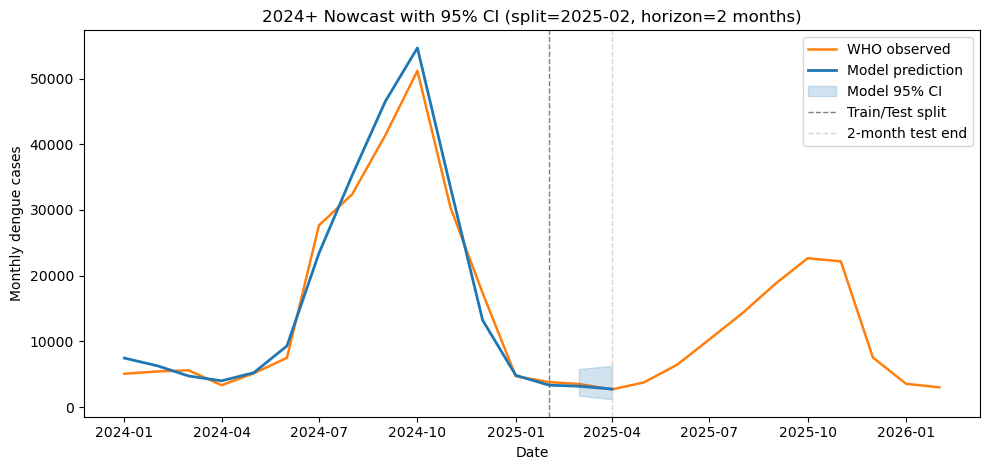

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-02.png


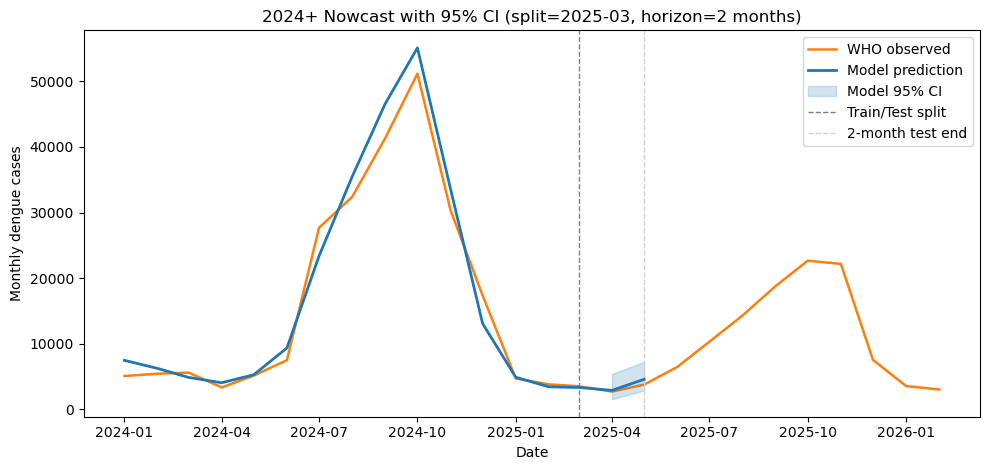

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-03.png


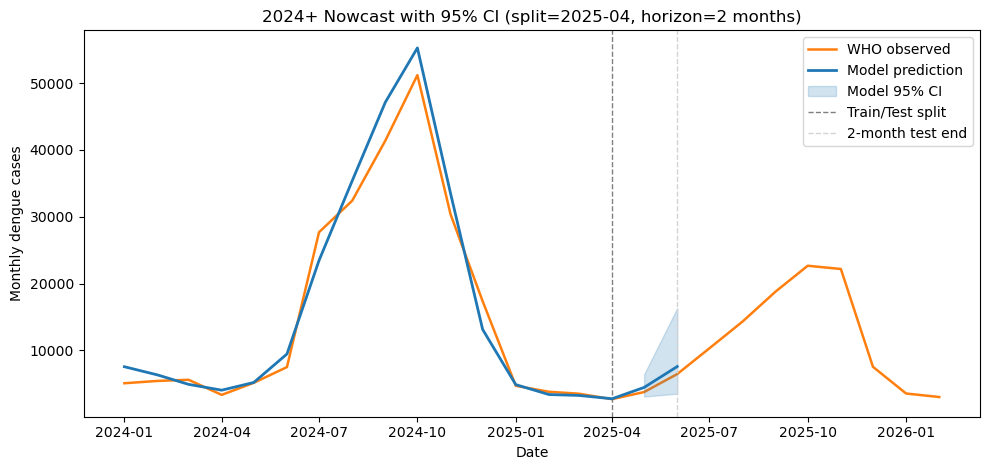

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-04.png


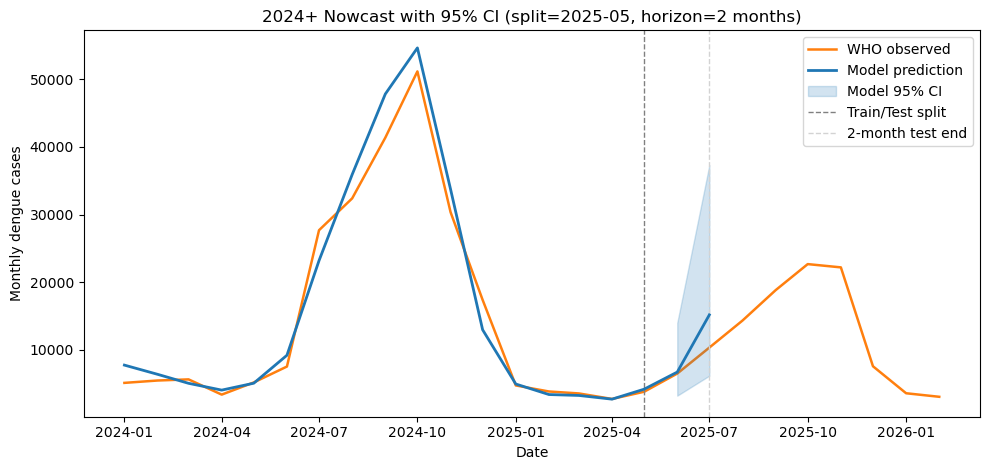

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-05.png


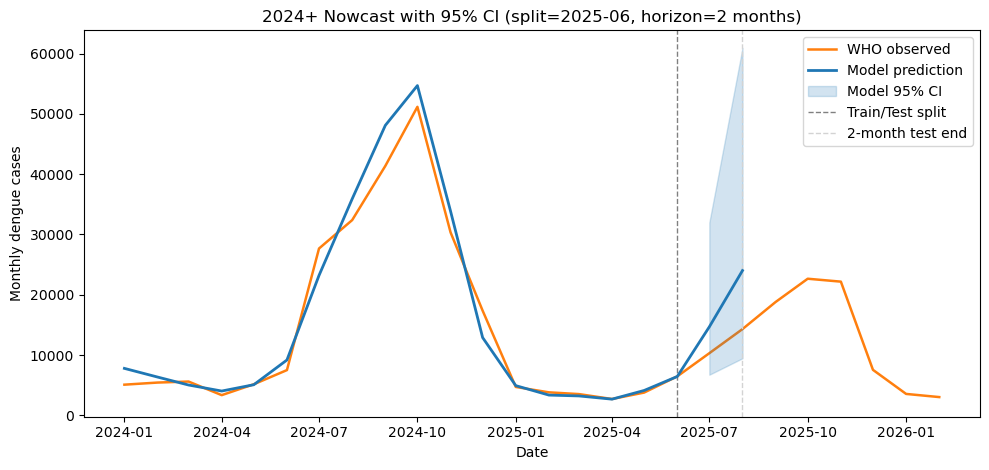

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-06.png


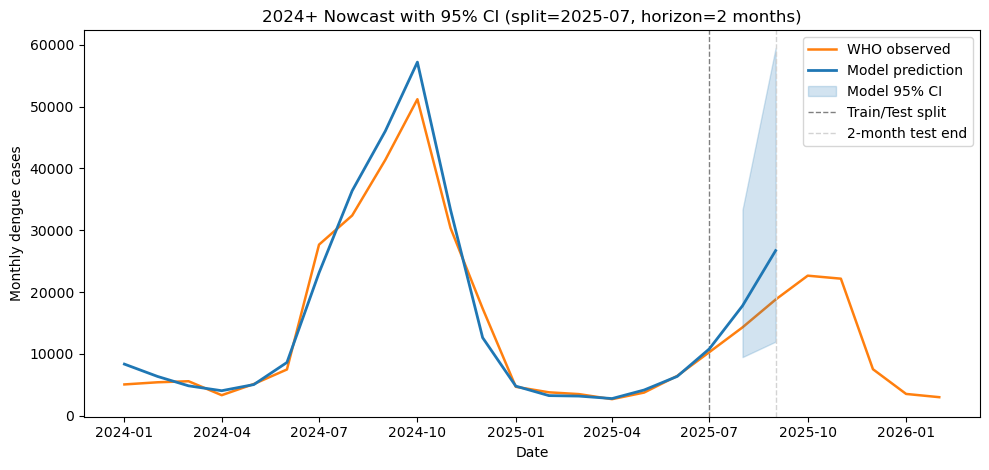

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-07.png


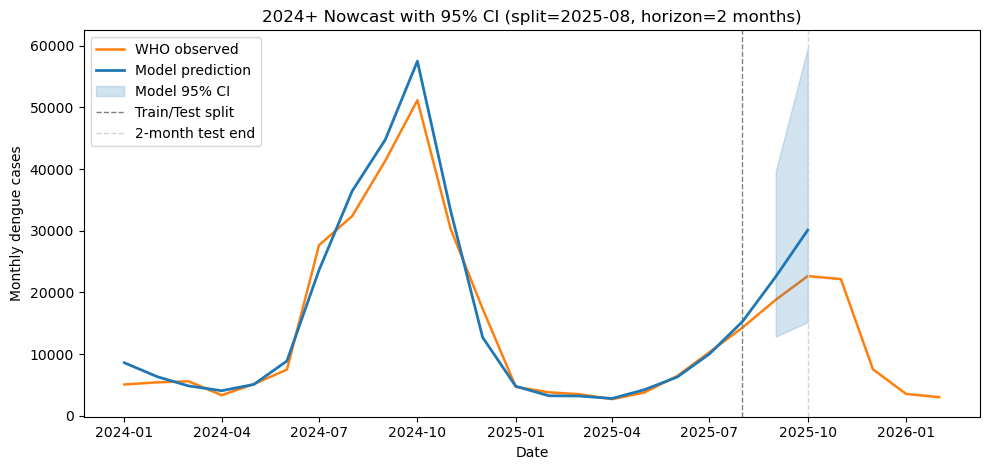

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-08.png


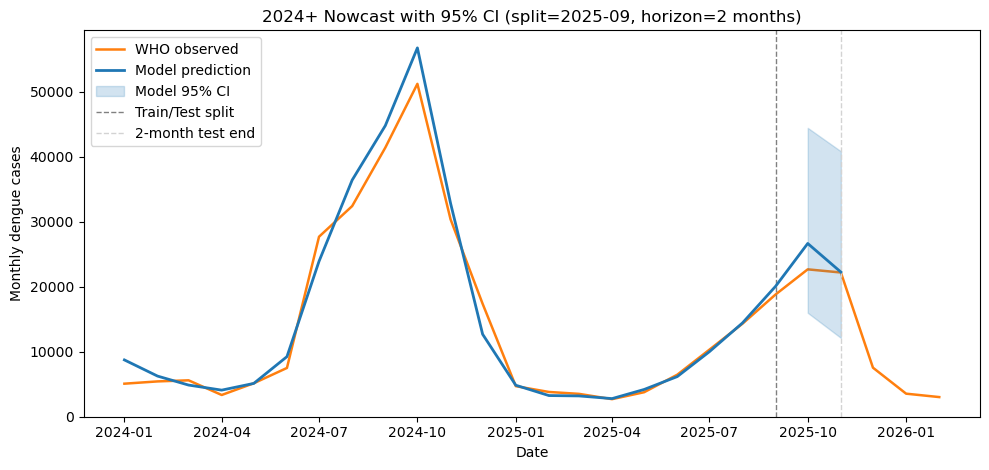

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-09.png


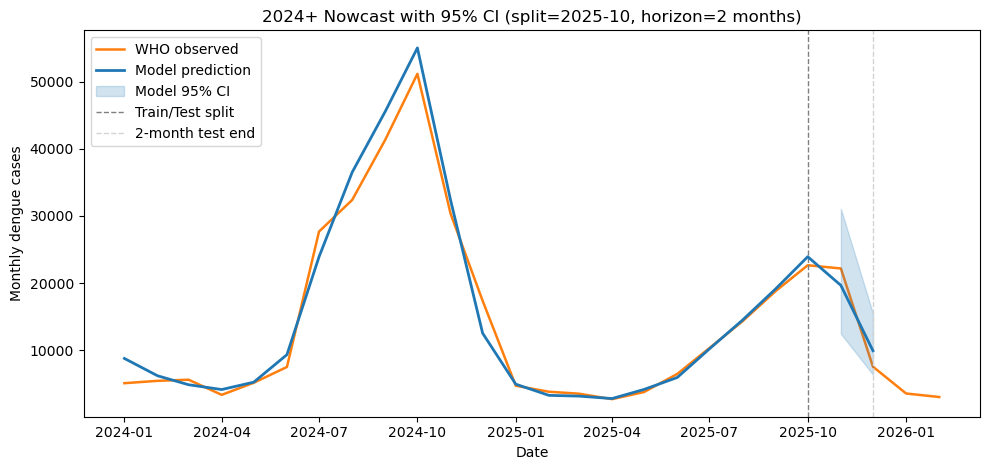

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-10.png


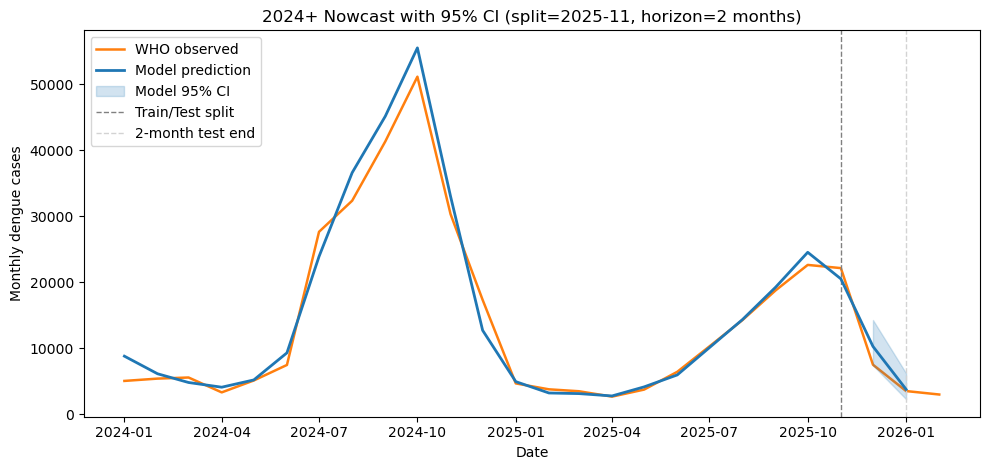

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-11.png


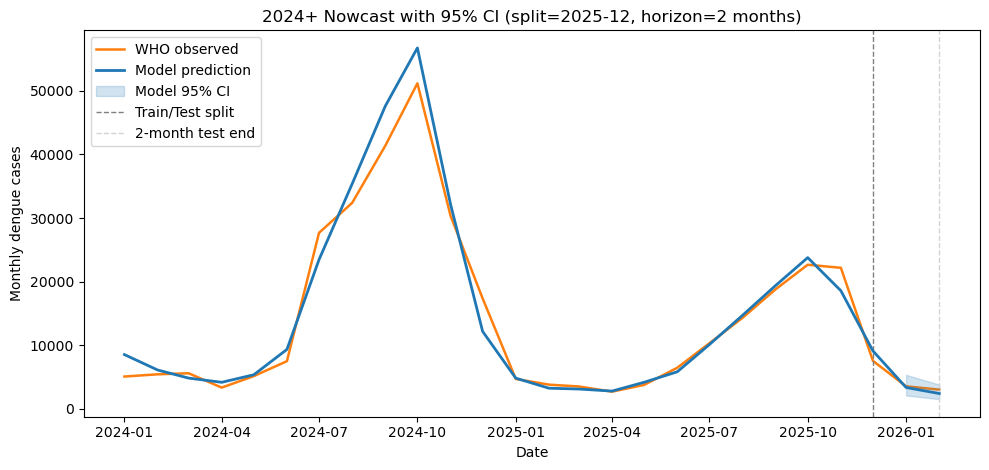

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2025-12.png


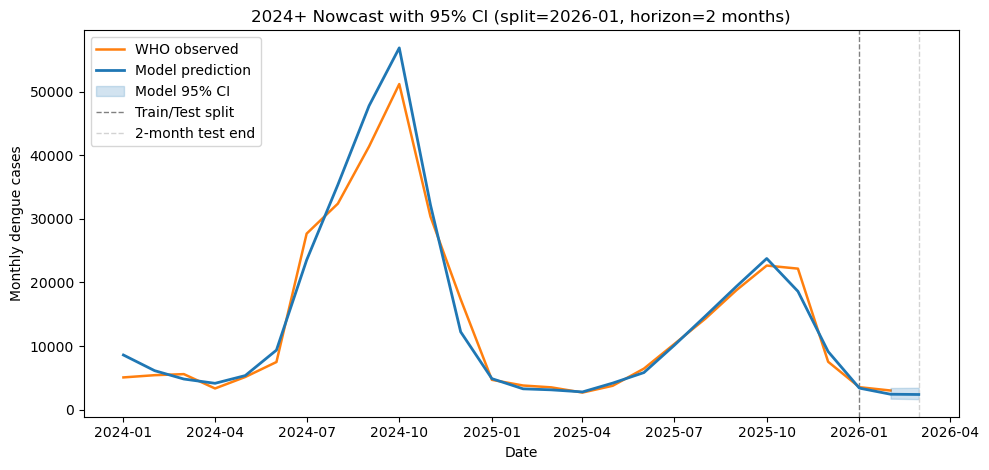

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2026-01.png


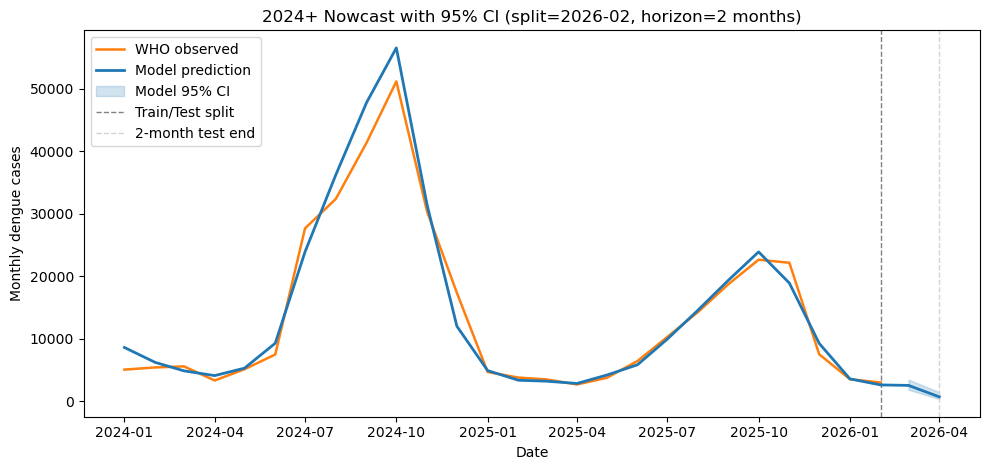

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/pred_ci_2month_test_window_split_2026-02.png
Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/rolling_prediction_intervals_2month_test_window_long.csv


In [20]:
# -------------------------
# Plot 2024+ WHO observations plus ONLY the 2-month test-window model predictions
# with 95% CI (one figure per rolling split)
# - show the model line only on the two post-split test months
# - show the CI band only on those same two months
# - do not shade the split/test region in the background
# -------------------------
from statistics import NormalDist
import re

if 'coef_long_df' not in globals() or len(coef_long_df) == 0:
    raise ValueError('coef_long_df is empty. Run the rolling split cell first.')

ci_rows = []

for split_month_ci in rolling_metrics_df['split_month'].tolist():
    train_mask, test_mask = time_series_split_mask(
        X_df.index,
        split_month_ci,
        horizon_months=int(cfg.test_horizon_months),
    )

    intercept_idx = feature_cols.index('intercept') if 'intercept' in feature_cols else None
    skip_cols = [intercept_idx] if intercept_idx is not None else []

    if cfg.standardize_features:
        X_proc, feat_mean, feat_std = standardize_features(X_raw, train_mask, skip_cols=skip_cols)
    else:
        X_proc = X_raw.copy()
        feat_mean = None
        feat_std = None

    year_constraints = build_year_constraints(X_df.index, yearly_proxy, train_mask)

    coef_sub = coef_long_df[coef_long_df['split_month'].eq(split_month_ci)].set_index('feature')
    beta_hat = np.array([float(coef_sub.loc[f, 'beta_hat']) for f in feature_cols], dtype=float)

    cfg_ci = copy.deepcopy(cfg)
    cfg_ci.split_month = split_month_ci
    x_pred = make_predictions(X_proc, beta_hat, cfg_ci)

    ci = compute_beta_ci_hessian(
        X=X_proc,
        y_who=y_who,
        mask_who=mask_who,
        year_constraints=year_constraints,
        train_mask=train_mask,
        cfg=cfg_ci,
        feature_cols=feature_cols,
        beta_hat=beta_hat,
        feat_mean=feat_mean,
        feat_std=feat_std,
        intercept_idx=intercept_idx,
        alpha=float(getattr(cfg_ci, 'beta_ci_alpha', 0.05)),
    )
    Var_beta = ci.get('Var_beta', None)
    z = float(ci.get('z', NormalDist().inv_cdf(0.975)))

    dates = pd.to_datetime(X_df.index)
    display_mask = (dates >= pd.Timestamp('2024-01-01'))
    test_idx = np.where(np.asarray(test_mask, dtype=bool))[0]
    if len(test_idx) == 0:
        print(f'Skipped CI plot for split {split_month_ci}: empty 2-month test window.')
        continue

    pred_se = np.full(len(dates), np.nan, dtype=float)
    pred_lo = np.full(len(dates), np.nan, dtype=float)
    pred_hi = np.full(len(dates), np.nan, dtype=float)

    if Var_beta is not None and np.isfinite(Var_beta).any():
        x_test = X_proc[test_idx, :]
        # SE in log1p-space (target_scale=1, so no multiplication needed)
        pred_se_log = np.sqrt(np.einsum('ij,jk,ik->i', x_test, Var_beta, x_test))
        pred_se[test_idx] = pred_se_log  # stored in log-space units
        # Recover log-space point prediction from already-expm1-transformed x_pred
        log_pred_test = x_test @ beta_hat   # exact log-space prediction (no round-trip distortion)
        # Asymmetric CI: back-transform from log-space (log-normal CI)
        pred_lo[test_idx] = np.expm1(log_pred_test - z * pred_se_log)
        pred_hi[test_idx] = np.expm1(log_pred_test + z * pred_se_log)
        # No clipping needed: expm1 of any finite value is > -1
    else:
        print(f'Warning for split {split_month_ci}: Var_beta not available, plotting test-window prediction without CI.')

    # Keep CI ONLY on the 2-month post-split test window,
    # but show the model prediction line from 2024-01 through the end of that test window.
    pred_lo_test_only = np.full(len(dates), np.nan, dtype=float)
    pred_hi_test_only = np.full(len(dates), np.nan, dtype=float)
    pred_lo_test_only[test_idx] = pred_lo[test_idx]
    pred_hi_test_only[test_idx] = pred_hi[test_idx]

    # Optional WHO CI if present in master_data as separate sources (e.g., WHO_lower/WHO_upper)
    who_lo = None
    who_hi = None
    cols = list(wide.columns)
    lo_cands = [c for c in cols if re.search(r'who.*(lower|lo|lci|lb)$', str(c), flags=re.I)]
    hi_cands = [c for c in cols if re.search(r'who.*(upper|hi|uci|ub)$', str(c), flags=re.I)]
    if len(lo_cands) > 0 and len(hi_cands) > 0:
        who_lo = wide[lo_cands[0]].reindex(dates).to_numpy(dtype=float)
        who_hi = wide[hi_cands[0]].reindex(dates).to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 4.8))

    # WHO observed line for context
    plt.plot(
        dates[display_mask],
        y_who[display_mask],
        linewidth=1.8,
        color='tab:orange',
        label='WHO observed',
        zorder=2,
    )

    # Optional WHO CI band
    if who_lo is not None and who_hi is not None:
        who_mask = dates >= pd.Timestamp('2024-01-01')
        plt.fill_between(
            dates[who_mask],
            who_lo[who_mask],
            who_hi[who_mask],
            alpha=0.12,
            label='WHO CI',
            zorder=1,
        )

    split_dt = pd.to_datetime(split_month_ci + '-01')
    test_end_dt = dates[test_mask].max() if np.asarray(test_mask).any() else None

    x_pred_plot_only = np.full(len(dates), np.nan, dtype=float)
    pred_line_mask = display_mask.copy()
    if test_end_dt is not None:
        pred_line_mask = pred_line_mask & (dates <= test_end_dt)
    x_pred_plot_only[pred_line_mask] = x_pred[pred_line_mask]

    # Model prediction line from 2024-01 up to the end of the 2-month test window
    plt.plot(
        dates[display_mask],
        x_pred_plot_only[display_mask],
        linewidth=2,
        color='tab:blue',
        label='Model prediction',
        zorder=3,
    )

    # Model CI band ONLY on the 2-month-ahead test window
    if np.isfinite(pred_lo_test_only[test_idx]).any() and np.isfinite(pred_hi_test_only[test_idx]).any():
        plt.fill_between(
            dates[display_mask],
            pred_lo_test_only[display_mask],
            pred_hi_test_only[display_mask],
            alpha=0.20,
            color='tab:blue',
            label='Model 95% CI',
            zorder=2,
        )

    if split_dt >= pd.Timestamp('2024-01-01'):
        plt.axvline(split_dt, linestyle='--', color='gray', linewidth=1.0, label='Train/Test split')
    if test_end_dt is not None and test_end_dt >= pd.Timestamp('2024-01-01'):
        plt.axvline(test_end_dt, linestyle='--', color='lightgray', linewidth=1.0, label='2-month test end')

    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title(f'2024+ Nowcast with 95% CI (split={split_month_ci}, horizon=2 months)')
    plt.legend(loc='best')
    plt.tight_layout()

    out_png = roll_dir / f'pred_ci_2month_test_window_split_{split_month_ci}.png'
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())

    ci_rows.append(pd.DataFrame({
        'split_month': split_month_ci,
        'date': dates.strftime('%Y-%m'),
        'is_display_window': display_mask.astype(int),
        'is_test_window': np.asarray(test_mask, dtype=int),
        'x_pred_test_window_only': np.where(np.asarray(test_mask, dtype=bool), x_pred, np.nan),
        'pred_se': pred_se,
        'pred_lo_95_test_window_only': pred_lo_test_only,
        'pred_hi_95_test_window_only': pred_hi_test_only,
    }))

if len(ci_rows) > 0:
    pred_ci_df = pd.concat(ci_rows, ignore_index=True)
    pred_ci_path = roll_dir / 'rolling_prediction_intervals_2month_test_window_long.csv'
    pred_ci_df.to_csv(pred_ci_path, index=False)
    print('Saved:', pred_ci_path.resolve())
else:
    print('No CI tables were saved.')



## 3) Plot and Save Outputs

Includes:
- Training loss curve
- WHO vs predictions (with train/test split line)
- Yearly aggregation vs OpenDengue
- Step1 vs Step2 comparison
- Parameter and prediction tables

Updated rolling evaluation uses only the next 2 months after each split as the test window, and prediction-interval plots are generated for every rolling split.


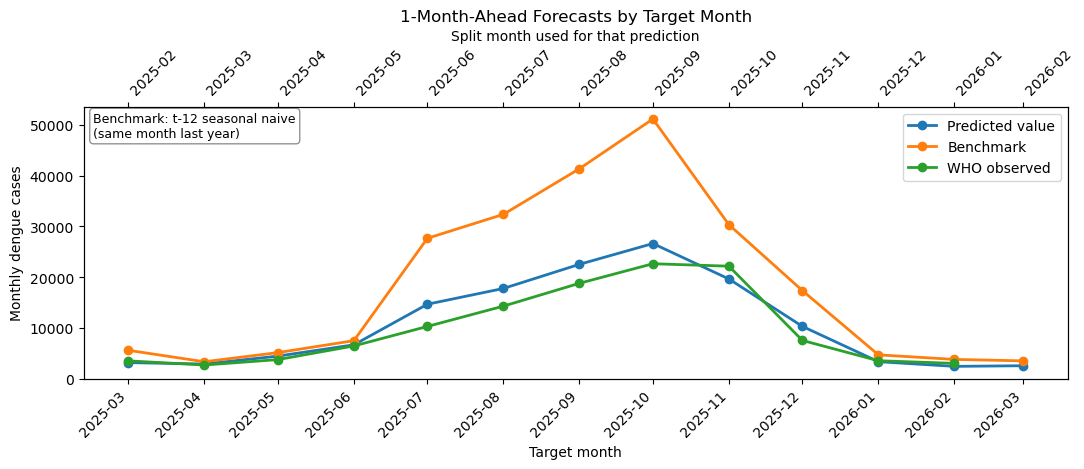

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/first_month_ahead_values.png


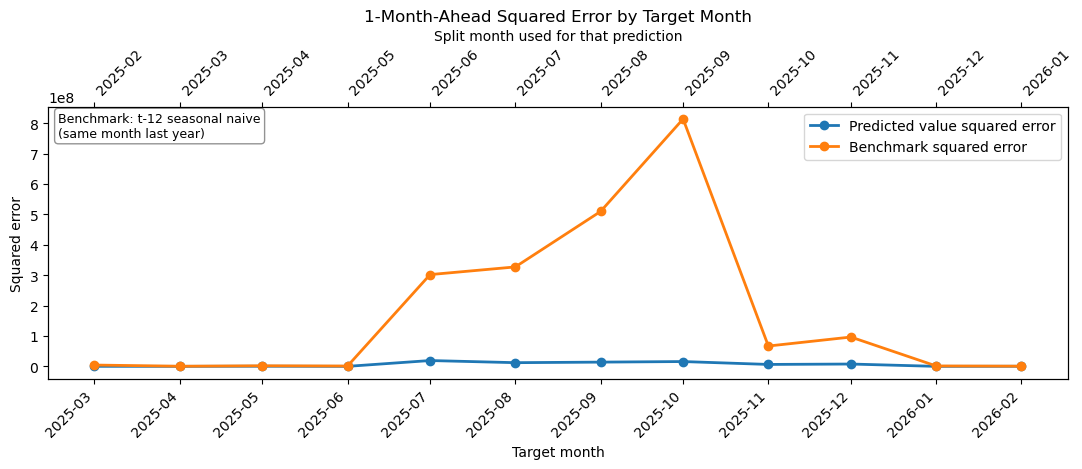

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/first_month_ahead_squared_error.png


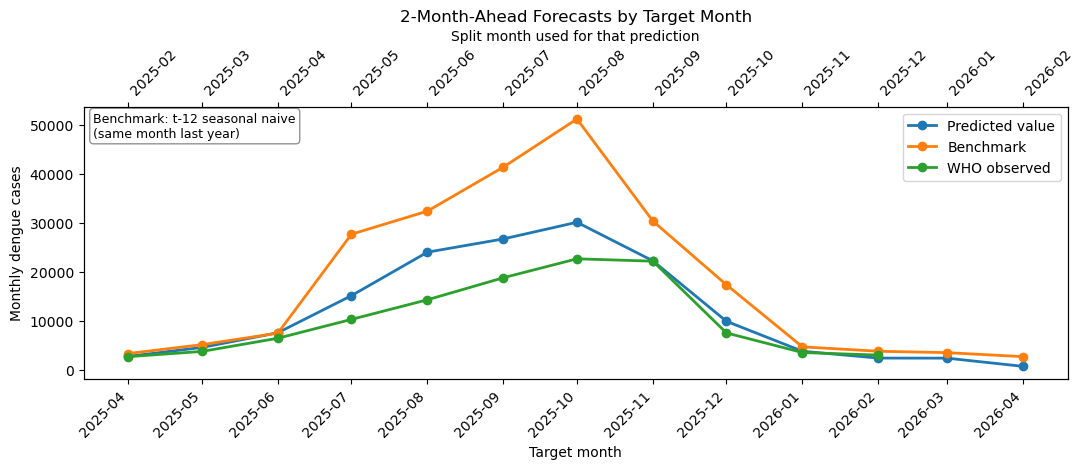

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/second_month_ahead_values.png


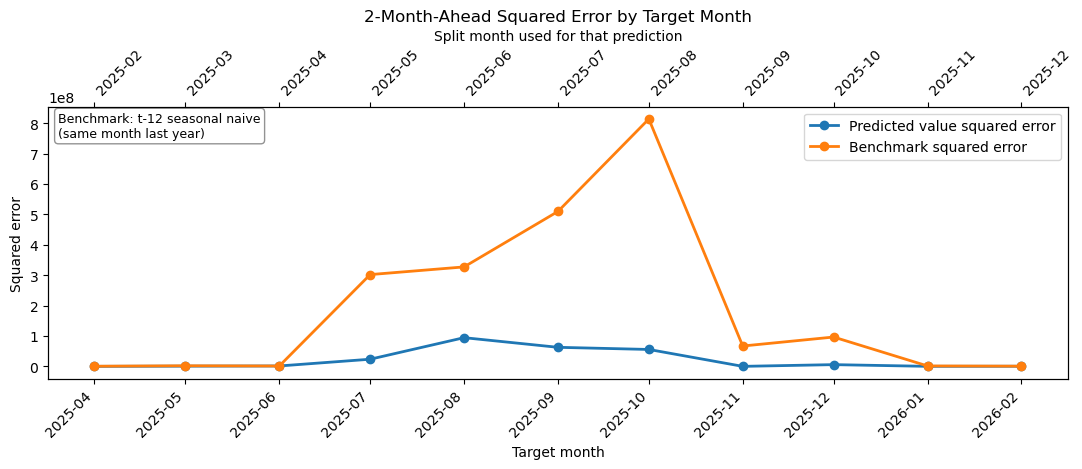

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/second_month_ahead_squared_error.png
Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_updated_nowcast_log/rolling_splits/horizon_specific_predictions_summary.csv


,split_month,split_date,target_month,target_date,horizon_step,x_pred,benchmark_t12,y_who,model_squared_error,benchmark_squared_error
0,2025-02,2025-02-01,2025-03,2025-03-01,1,3175.893972,5597.002441,3517.0,1.163533e+05,4.326410e+06
1,2025-03,2025-03-01,2025-04,2025-04-01,1,2889.726219,3342.000488,2700.0,3.599604e+04,4.121646e+05
2,2025-04,2025-04-01,2025-05,2025-05-01,1,4453.695664,5144.998535,3766.0,4.729253e+05,1.901637e+06
3,2025-05,2025-05-01,2025-06,2025-06-01,1,6677.970197,7498.997559,6459.0,4.794795e+04,1.081595e+06
4,2025-06,2025-06-01,2025-07,2025-07-01,1,14678.738997,27675.005859,10302.0,1.915584e+07,3.018213e+08


In [18]:
# -------------------------
# Horizon-specific results: first month ahead vs second month ahead
# Outputs: 4 figures
#   1) first-month-ahead values
#   2) first-month-ahead squared errors
#   3) second-month-ahead values
#   4) second-month-ahead squared errors
# -------------------------
if 'rolling_pred_df' not in globals() or len(rolling_pred_df) == 0:
    pred_path = roll_dir / 'rolling_predictions_long.csv'
    if pred_path.exists():
        rolling_pred_df = pd.read_csv(pred_path)
    else:
        raise ValueError('rolling_pred_df is empty. Run the rolling split cell first.')

plot_df = rolling_pred_df.copy()
plot_df['target_date'] = pd.to_datetime(plot_df['target_date'])
plot_df['split_date'] = pd.to_datetime(plot_df['split_date'])
plot_df = plot_df.sort_values(['horizon_step', 'target_date', 'split_date']).reset_index(drop=True)


def add_target_and_split_axes(ax, sub: pd.DataFrame) -> None:
    ticks = sub['target_date'].tolist()
    ax.set_xticks(ticks)
    ax.set_xticklabels(sub['target_month'].tolist(), rotation=45, ha='right')
    ax.set_xlabel('Target month')

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels(sub['split_month'].tolist(), rotation=45, ha='left')
    ax_top.set_xlabel('Split month used for that prediction')


def add_benchmark_note(ax) -> None:
    ax.text(
        0.01, 0.98,
        'Benchmark: t-12 seasonal naive\n(same month last year)',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'),
    )


def plot_horizon_values(sub: pd.DataFrame, horizon_step: int, out_png: Path) -> None:
    fig = plt.figure(figsize=(11, 4.8))
    plt.plot(
        sub['target_date'], sub['x_pred'],
        marker='o', linewidth=2, color='tab:blue',
        label='Predicted value',
        zorder=1
    )
    plt.plot(
        sub['target_date'], sub['benchmark_t12'],
        marker='o', linewidth=2, color='tab:orange',
        label='Benchmark',
        zorder=2
    )
    plt.plot(
        sub['target_date'], sub['y_who'],
        marker='o', linewidth=2, color='tab:green',
        label='WHO observed',
        zorder=3
    )
    plt.ylabel('Monthly dengue cases')
    plt.title(f'{horizon_step}-Month-Ahead Forecasts by Target Month')
    ax = plt.gca()
    add_target_and_split_axes(ax, sub)
    add_benchmark_note(ax)
    ax.legend(loc='upper right')
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())


def plot_horizon_errors(sub: pd.DataFrame, horizon_step: int, out_png: Path) -> None:
    err = sub.copy()
    err = err[np.isfinite(err['model_squared_error']) | np.isfinite(err['benchmark_squared_error'])].copy()
    fig = plt.figure(figsize=(11, 4.8))
    plt.plot(
        err['target_date'], err['model_squared_error'],
        marker='o', linewidth=2, color='tab:blue',
        label='Predicted value squared error',
        zorder=1
    )
    plt.plot(
        err['target_date'], err['benchmark_squared_error'],
        marker='o', linewidth=2, color='tab:orange',
        label='Benchmark squared error',
        zorder=2
    )
    plt.ylabel('Squared error')
    plt.title(f'{horizon_step}-Month-Ahead Squared Error by Target Month')
    ax = plt.gca()
    add_target_and_split_axes(ax, err)
    add_benchmark_note(ax)
    ax.legend(loc='upper right')
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())


for horizon_step, tag in [(1, 'first'), (2, 'second')]:
    sub = plot_df[plot_df['horizon_step'].eq(horizon_step)].copy()
    if sub.empty:
        print(f'No rows found for horizon_step={horizon_step}.')
        continue

    value_png = roll_dir / f'{tag}_month_ahead_values.png'
    error_png = roll_dir / f'{tag}_month_ahead_squared_error.png'
    plot_horizon_values(sub, horizon_step, value_png)
    plot_horizon_errors(sub, horizon_step, error_png)

summary_cols = [
    'split_month', 'target_month', 'horizon_step',
    'x_pred', 'benchmark_t12', 'y_who',
    'model_squared_error', 'benchmark_squared_error'
]
summary_path = roll_dir / 'horizon_specific_predictions_summary.csv'
plot_df.loc[:, summary_cols].to_csv(summary_path, index=False)
print('Saved:', summary_path.resolve())

plot_df.head()
